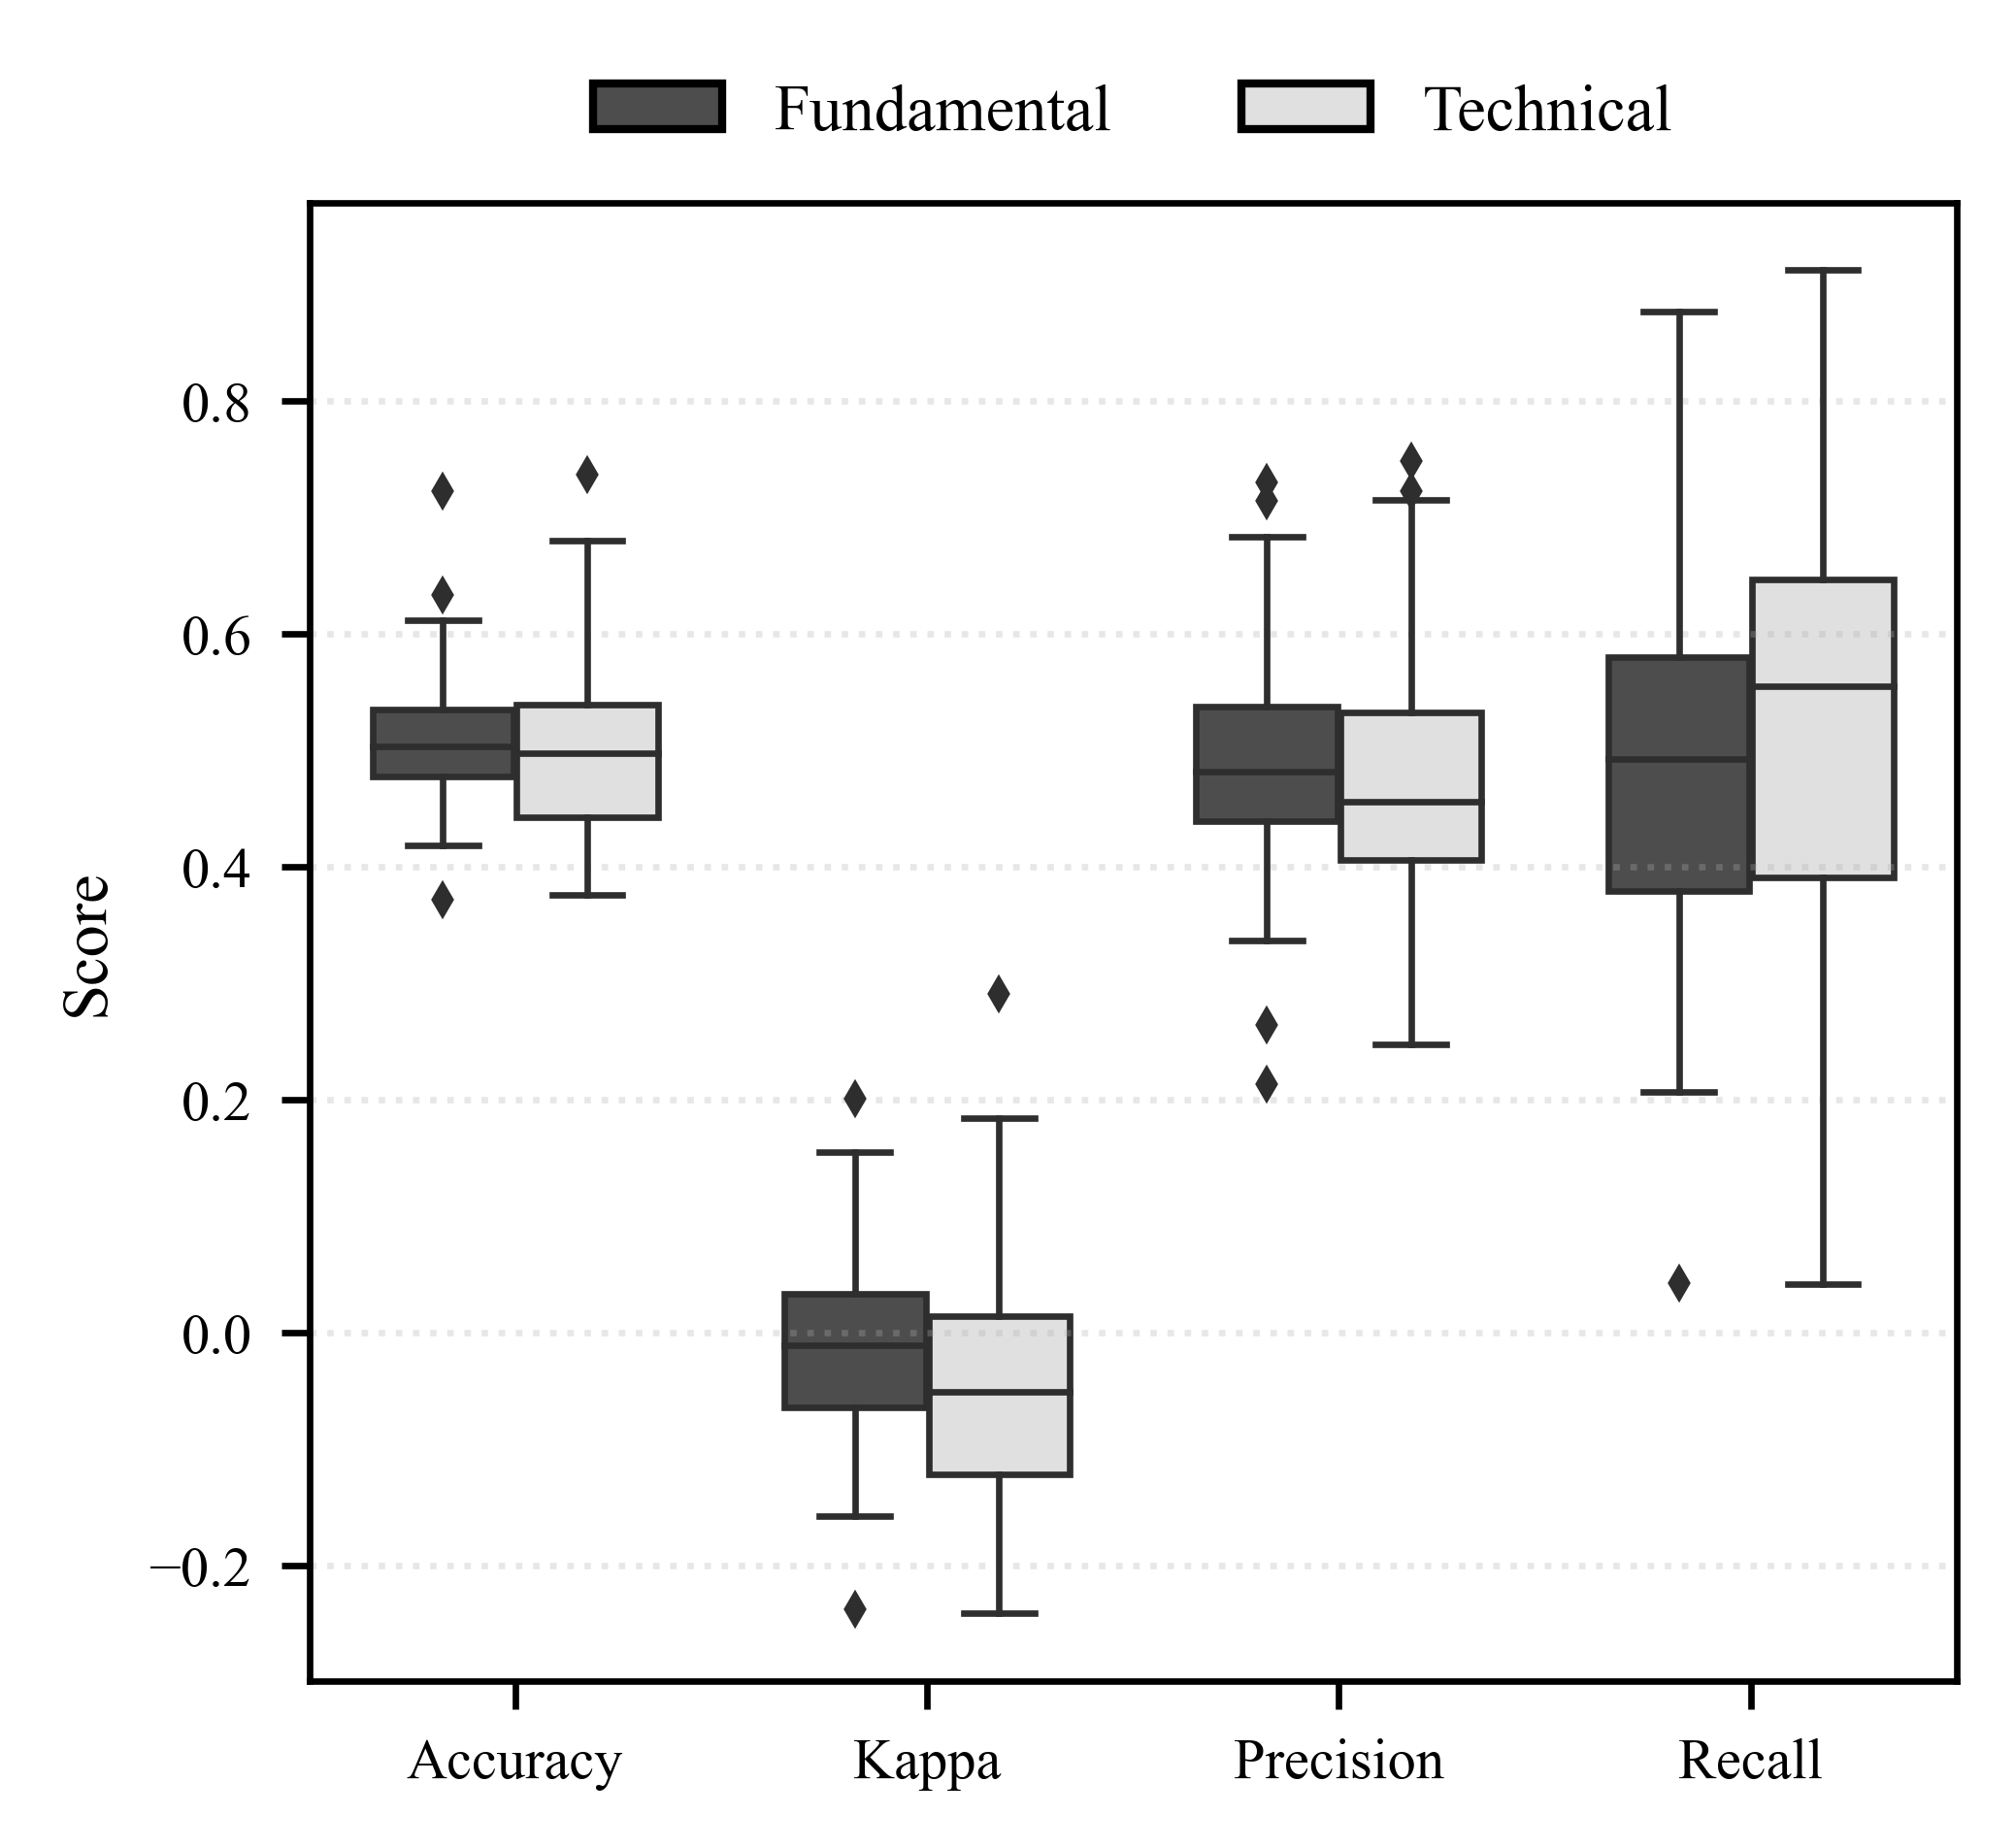

Gráfico salvo: figuras/metrics_distribution_lag1.pdf

RELATÓRIO ESTATÍSTICO DE PERFORMANCE POR DOMÍNIO
Quantidade Inicial de Ativos (no CSV de resultados): 64
Quantidade FINAL de Ativos (após filtros 2023/LEVE3): 58
Ativos Considerados: ABCB4, ALPA4, AMER3, BBAS3, BBDC3, BBDC4, BEEF3, BRFS3, BRSR6, CCRO3, CIEL3, CMIG3, CMIG4, CPFE3, CSUD3, CYRE3, DIRR3, DXCO3, ELET3, ELET6, EMBR3, ENBR3, EQTL3, FESA4, FHER3, GFSA3, GGBR3, GGBR4, GRND3, HBOR3, HYPE3, ITUB3, ITUB4, KEPL3, LOGN3, LREN3, MDIA3, MILS3, MULT3, MYPK3, NEXP3, ODPV3, PDGR3, PETR3, PETR4, POMO4, POSI3, RADL3, RENT3, RSID3, SAPR4, SLCE3, TOTS3, TRPL4, UNIP6, USIM3, USIM5, VALE3
--------------------------------------------------------------------------------

>>> MÉTRICA: ACCURACY
Domain         Fundamental  Technical
N                  58.0000    58.0000
Média               0.5105     0.4990
Desvio Padrão       0.0603     0.0758
Mínimo              0.3713     0.3753
Q1 (25%)            0.4770     0.4418
Mediana (50%)       0.5031

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# ==============================================================================
# 1. CONFIGURAÇÃO DE FONTE E ESTILO (PADRÃO IEEE)
# ==============================================================================
caminhos_possiveis = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

caminho_fonte = None
for p in caminhos_possiveis:
    if os.path.exists(p):
        caminho_fonte = p
        break

try:
    if caminho_fonte:
        fm.fontManager.addfont(caminho_fonte)
        prop = fm.FontProperties(fname=caminho_fonte)
        nome_exato_fonte = prop.get_name()
    else:
        nome_exato_fonte = 'serif'
except:
    nome_exato_fonte = 'serif'

# Configurações IEEE
IEEE_COL_WIDTH = 3.5
IEEE_HEIGHT = 3.2 

plt.rcParams.update({
    'font.family': nome_exato_fonte,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

palette_map = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'}

# ==============================================================================
# 2. CARREGAMENTO E CÁLCULO DAS MÉTRICAS (POR ATIVO)
# ==============================================================================
caminho_arquivo = 'resultados/resultados_HT_atraso_1.csv' 
mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}

# Variáveis para contagem
total_inicial_ativos = 0
total_final_ativos = 0
lista_ativos_finais = []

if os.path.exists(caminho_arquivo):
    df = pd.read_csv(caminho_arquivo)
    
    # Contagem inicial (antes dos filtros)
    total_inicial_ativos = df['base'].nunique()

    # --- FILTRAGEM ---
    try:
        df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
        if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
            df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

        # Ativos presentes em 2023
        papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
        
        # Filtros
        df = df[df['base'].isin(papeis)]
        df = df[~df['base'].isin(['LEVE3'])] # Exclusão explícita
        
        # Contagem final
        total_final_ativos = df['base'].nunique()
        lista_ativos_finais = df['base'].unique()
        
    except Exception as e:
        print(f"Erro ao filtrar ativos: {e}")
        total_final_ativos = df['base'].nunique()

    # Mapear nomes
    df['Domain'] = df['categoria'].map(mapa_nomes)
    
    # Agrupar por Ativo (Base) e Domínio
    df_assets = df.groupby(['base', 'Domain'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()
    
    # Cálculo das Métricas
    total = df_assets['TP'] + df_assets['TN'] + df_assets['FP'] + df_assets['FN']
    
    df_assets['Accuracy'] = (df_assets['TP'] + df_assets['TN']) / total
    
    # Precision
    df_assets['Precision'] = df_assets['TP'] / (df_assets['TP'] + df_assets['FP'])
    df_assets['Precision'] = df_assets['Precision'].fillna(0)
    
    # Recall
    df_assets['Recall'] = df_assets['TP'] / (df_assets['TP'] + df_assets['FN'])
    df_assets['Recall'] = df_assets['Recall'].fillna(0)
    
    # Kappa
    po = df_assets['Accuracy']
    pe_pos = ((df_assets['TP'] + df_assets['FP']) * (df_assets['TP'] + df_assets['FN'])) / (total**2)
    pe_neg = ((df_assets['TN'] + df_assets['FN']) * (df_assets['TN'] + df_assets['FP'])) / (total**2)
    pe = pe_pos + pe_neg
    df_assets['Kappa'] = (po - pe) / (1 - pe)
    
else:
    print("AVISO: Arquivo não encontrado. Dados simulados.")
    # (Código de simulação omitido para brevidade, mas o relatório funcionaria igual se existisse df_assets)
    df_assets = pd.DataFrame() 

# ==============================================================================
# 3. PLOTAGEM (BOXPLOT)
# ==============================================================================
if not df_assets.empty:
    metrics_to_plot = ['Accuracy', 'Kappa', 'Precision', 'Recall']
    df_melted = df_assets.melt(id_vars=['base', 'Domain'], 
                               value_vars=metrics_to_plot, 
                               var_name='Metric', value_name='Score')

    fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH, IEEE_HEIGHT))

    sns.boxplot(
        data=df_melted, x='Metric', y='Score', hue='Domain',
        palette=palette_map,
        linewidth=0.8,
        fliersize=2,
        saturation=1,
        width=0.7,
        ax=ax
    )

    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_title('')
    # ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

    handles = [Patch(facecolor=palette_map['Fundamental'], edgecolor='black', label='Fundamental'),
               Patch(facecolor=palette_map['Technical'], edgecolor='black', label='Technical')]

    ax.legend(handles=handles, labels=['Fundamental', 'Technical'], 
              loc='upper center', bbox_to_anchor=(0.5, 1.12), 
              ncol=2, frameon=False, fontsize=8)

    plt.tight_layout()
    nome_saida = 'figuras/metrics_distribution_lag1.pdf'
    plt.savefig(nome_saida, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    print(f"Gráfico salvo: {nome_saida}")

# ==============================================================================
# 4. RELATÓRIO ESTATÍSTICO DETALHADO
# ==============================================================================
print("\n" + "="*80)
print("RELATÓRIO ESTATÍSTICO DE PERFORMANCE POR DOMÍNIO")
print("="*80)

# 1. Contagem de Ativos
print(f"Quantidade Inicial de Ativos (no CSV de resultados): {total_inicial_ativos}")
print(f"Quantidade FINAL de Ativos (após filtros 2023/LEVE3): {total_final_ativos}")
if total_final_ativos > 0:
    print(f"Ativos Considerados: {', '.join(sorted(lista_ativos_finais))}")
print("-" * 80)

if not df_assets.empty:
    # 2. Cálculo das estatísticas descritivas
    # Agrupamos por Domain e pedimos 'describe' das métricas
    metrics_cols = ['Accuracy', 'Kappa', 'Precision', 'Recall']
    stats_df = df_assets.groupby('Domain')[metrics_cols].describe(percentiles=[0.25, 0.5, 0.75])

    # 3. Formatação e Impressão
    # Iteramos sobre cada métrica para imprimir blocos separados, facilitando a leitura
    for metric in metrics_cols:
        print(f"\n>>> MÉTRICA: {metric.upper()}")
        
        # Seleciona apenas as colunas daquela métrica no describe multi-index
        subset = stats_df[metric]
        
        # Renomeia colunas para ficar mais claro
        subset = subset.rename(columns={
            'count': 'N',
            'mean': 'Média',
            'std': 'Desvio Padrão',
            'min': 'Mínimo',
            '25%': 'Q1 (25%)',
            '50%': 'Mediana (50%)',
            '75%': 'Q3 (75%)',
            'max': 'Máximo'
        })
        
        # Formata para float com 4 casas
        print(subset.T.to_string(float_format="{:.4f}".format))
        print("-" * 40)

    # 4. Análise de Dispersão (IQR)
    print("\n>>> ANÁLISE DE DISPERSÃO (IQR = Q3 - Q1)")
    iqr_data = []
    for metric in metrics_cols:
        subset = stats_df[metric]
        iqr_fund = subset.loc['Fundamental', '75%'] - subset.loc['Fundamental', '25%']
        iqr_tech = subset.loc['Technical', '75%'] - subset.loc['Technical', '25%']
        iqr_data.append({'Metric': metric, 'IQR Fundamental': iqr_fund, 'IQR Technical': iqr_tech})
    
    df_iqr = pd.DataFrame(iqr_data)
    print(df_iqr.to_string(index=False, float_format="{:.4f}".format))

print("="*80 + "\n")

# ==============================================================================
# 5. SALVAR RELATÓRIO EM CSV
# ==============================================================================
if not stats_df.empty:
    print("\nGerando arquivo CSV do relatório...")
    
    # "Achatar" o MultiIndex para um formato tabular amigável (Excel/CSV)
    # Stack level 0 traz as Métricas (Accuracy, Kappa...) para as linhas
    report_csv = stats_df.stack(level=0).reset_index()
    
    # Renomear as colunas para ficar bonito
    report_csv = report_csv.rename(columns={
        'level_1': 'Metric',
        'count': 'Count',
        'mean': 'Mean',
        'std': 'Std_Dev',
        'min': 'Min',
        '25%': 'Q1',
        '50%': 'Median',
        '75%': 'Q3',
        'max': 'Max'
    })
    
    # Reordenar colunas para leitura lógica
    cols_order = ['Domain', 'Metric', 'Count', 'Mean', 'Median', 'Std_Dev', 'Min', 'Q1', 'Q3', 'Max']
    report_csv = report_csv[cols_order]
    
    # Salvar
    nome_csv = 'tabela_estatistica_descritiva.csv'
    report_csv.to_csv(nome_csv, index=False, float_format='%.4f')
    
    print(f"Sucesso! Relatório salvo em: {os.path.abspath(nome_csv)}")
    print("="*80)
else:
    print("Sem dados para salvar.")

Agrupando por ativo (média dos horizontes)...


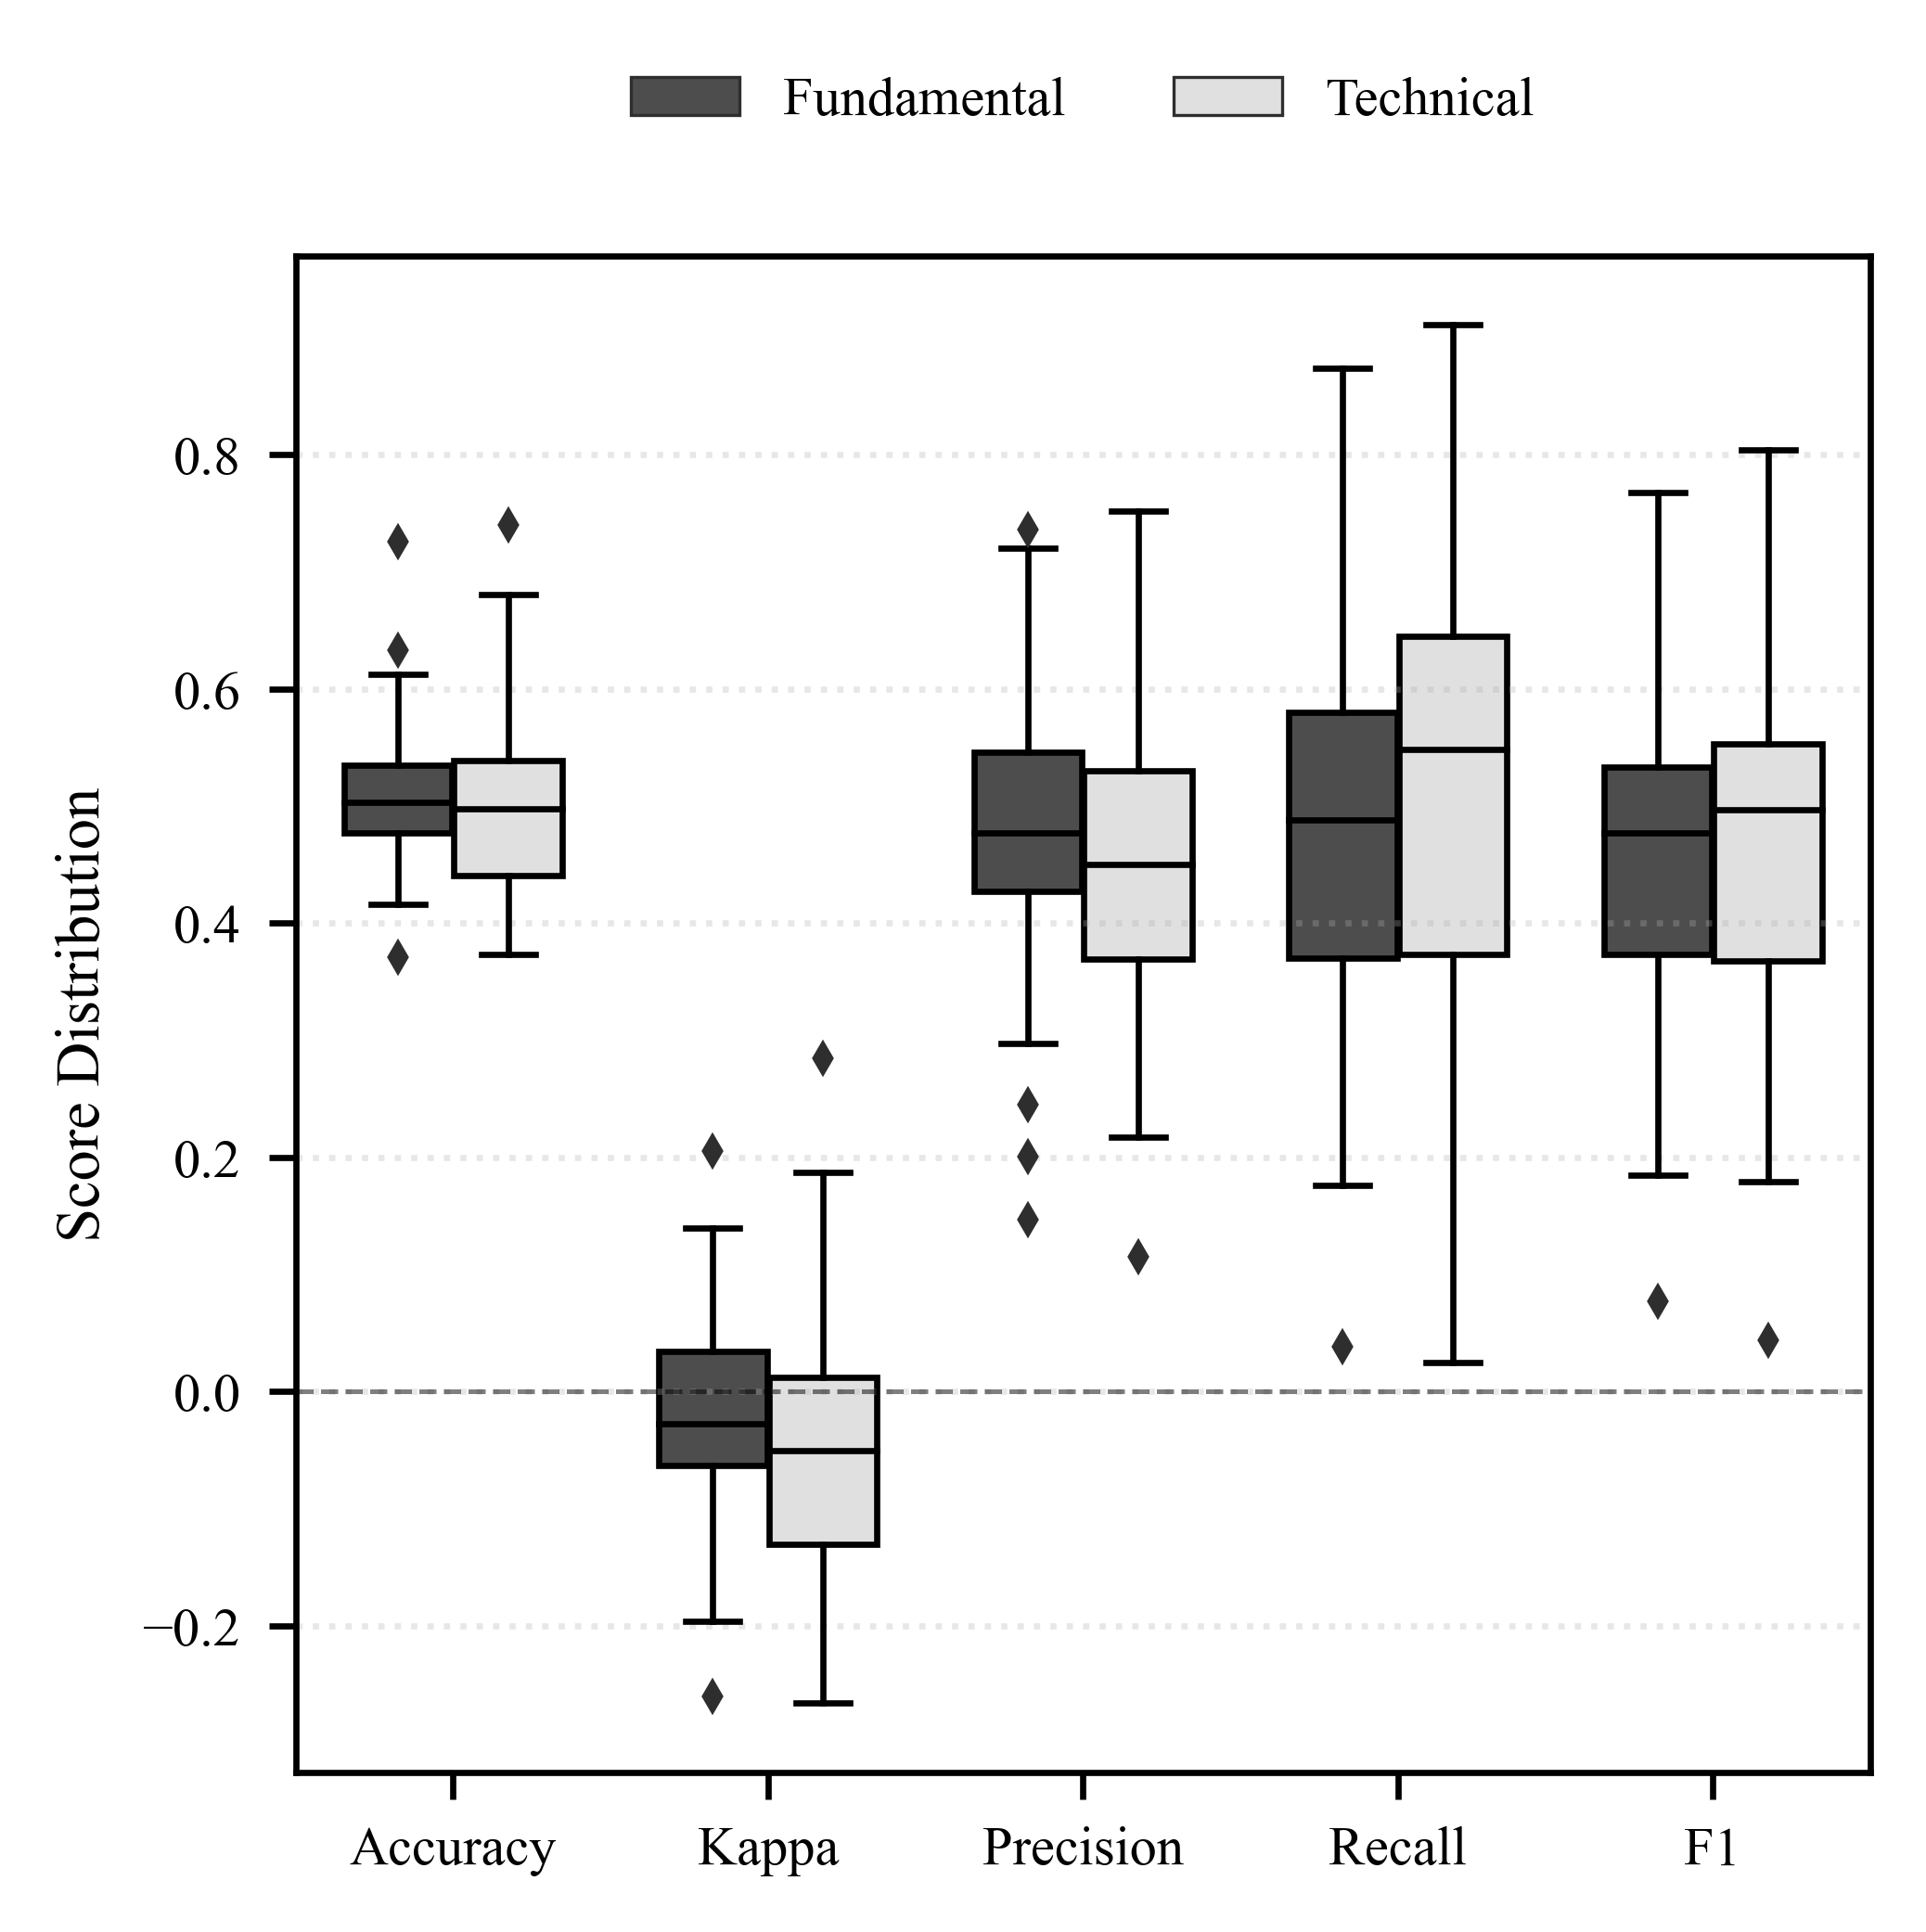

Gráfico salvo: figuras/metrics_distribution_lag1.pdf

DETALHAMENTO ESTATÍSTICO DOS BOXPLOTS (58 ATIVOS)
                       Base da Caixa (Q1)  Mediana  Topo da Caixa (Q3)
Metric    Domain                                                      
Accuracy  Fundamental              0.4769   0.5032              0.5352
          Technical                0.4402   0.4975              0.5384
Kappa     Fundamental             -0.0629  -0.0274              0.0347
          Technical               -0.1302  -0.0507              0.0119
Precision Fundamental              0.4269   0.4771              0.5459
          Technical                0.3697   0.4499              0.5303
Recall    Fundamental              0.3703   0.4877              0.5802
          Technical                0.3733   0.5481              0.6450
F1        Fundamental              0.3733   0.4769              0.5331
          Technical                0.3675   0.4969              0.5527

INTERPRETAÇÃO RÁPIDA:
- Se a Mediana do Fun

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.font_manager as fm

# ==============================================================================
# 1. CARREGAMENTO FORÇADO DA FONTE
# ==============================================================================
caminhos_possiveis = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

caminho_fonte = None
for p in caminhos_possiveis:
    if os.path.exists(p):
        caminho_fonte = p
        break

try:
    if caminho_fonte:
        fm.fontManager.addfont(caminho_fonte)
        prop = fm.FontProperties(fname=caminho_fonte)
        nome_exato_fonte = prop.get_name()
    else:
        nome_exato_fonte = 'serif'
except:
    nome_exato_fonte = 'serif'

# ==============================================================================
# 2. CONFIGURAÇÕES IEEE
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1 
caminho_base = 'resultados'
nome_arquivo_saida = f'figuras/metrics_distribution_lag{atraso_selecionado}.pdf'

plt.rcParams.update({
    'font.family': nome_exato_fonte,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'lines.markersize': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_pb = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'} 

# ==============================================================================
# 3. CARREGAMENTO E PROCESSAMENTO
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

try:
    if os.path.exists(caminho_completo):
        df = pd.read_csv(caminho_completo)
        df_vmob = pd.read_csv('/home/jjos/profit_performance/valor_mobiliario.csv')
    # ensure the column is datetime-like before using .dt
        if not pd.api.types.is_datetime64_any_dtype(df_vmob['Data_Referencia']):
            df_vmob['Data_Referencia'] = pd.to_datetime(df_vmob['Data_Referencia'], errors='coerce')

            papeis = df_vmob[df_vmob['Data_Referencia'].dt.year == 2023].Codigo_Negociacao.unique()
            papeis_anteriores = df['base'].unique()
            df = df[df['base'].isin(papeis)]
            df = df[~df['base'].isin(['LEVE3'])]  # Exclude LEVE3 and LEVE4 due to not ajusted prices
    else:
        # MOCK DE DADOS (CASO NÃO TENHA O ARQUIVO AGORA)
        print("AVISO: Usando dados mockados.")
        data = []
        bases = [f'Ativo_{i}' for i in range(58)]
        horizontes = [1, 30, 60, 90, 120, 150, 180, 210, 240]
        for b in bases:
            for h in horizontes:
                for cat in ['fund', 'nao_fund']:
                    data.append({
                        'base': b, 'fh': h, 'categoria': cat,
                        'Accuracy': 0.52 + np.random.normal(0, 0.05),
                        'Kappa': 0.02 + np.random.normal(0, 0.05),
                        'Precision': 0.51 + np.random.normal(0, 0.05),
                        'Recall': 0.53 + np.random.normal(0, 0.05)
                    })
        df = pd.DataFrame(data)

    # Limpeza e Conversão
    cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    for col in cols_numericas:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'F1' not in df.columns or df['F1'].isnull().all():
        if 'Precision' in df.columns and 'Recall' in df.columns:
            df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)

    df['Domain'] = df['categoria'].map(mapa_nomes)
    
    # 3.1. AGREGAÇÃO POR ATIVO (PASSO CRÍTICO ADICIONADO)
    # -------------------------------------------------------------------------
    # Isso garante que o boxplot mostre a distribuição dos 58 ATIVOS
    # (média de todos os horizontes para cada ativo), removendo o ruído dos horizontes.
    metricas_disponiveis = [m for m in cols_numericas if m in df.columns]
    
    # Agrupa por Ativo ('base') e Domínio -> Tira a média das métricas
    if 'base' in df.columns:
        print("Agrupando por ativo (média dos horizontes)...")
        df_agrupado = df.groupby(['base', 'Domain'])[metricas_disponiveis].mean().reset_index()
    else:
        print("AVISO: Coluna 'base' não encontrada. Usando dados brutos.")
        df_agrupado = df

    # Prepara para plotagem
    ordem_metricas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    metricas_finais = [m for m in ordem_metricas if m in metricas_disponiveis]

    df_melted = df_agrupado.melt(
        id_vars=['Domain'], 
        value_vars=metricas_finais,
        var_name='Metric', 
        value_name='Score'
    )

    # ==============================================================================
    # 4. PLOTAGEM
    # ==============================================================================
    plt.figure(figsize=(3.5, 3.5))

    ax = sns.boxplot(
        data=df_melted,
        x='Metric', y='Score', hue='Domain',
        palette=palette_pb,
        linewidth=0.8,
        fliersize=2,
        width=0.7,
        saturation=1
    )

    # Borda preta e preenchimento colorido
    for i, artist in enumerate(ax.artists):
        artist.set_edgecolor('black')
        
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.8)

    plt.xlabel('') 
    plt.ylabel('Score Distribution')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=0.6, alpha=0.5)
    
    plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.15), 
               ncol=2, frameon=False, fontsize=7)

    plt.tight_layout()
    
    # plt.savefig(nome_arquivo_saida, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    # ... (seu código de plotagem anterior) ...
    
    print(f"Gráfico salvo: {nome_arquivo_saida}")

    # ==============================================================================
    # 5. CÁLCULO E EXIBIÇÃO DAS ESTATÍSTICAS
    # ==============================================================================
    print("\n" + "="*60)
    print("DETALHAMENTO ESTATÍSTICO DOS BOXPLOTS (58 ATIVOS)")
    print("="*60)

    # Agrupa pelos mesmos critérios do gráfico (Métrica e Domínio)
    # Calcula os quantis: 0.25 (Base), 0.50 (Mediana), 0.75 (Topo)
    estatisticas = df_melted.groupby(['Metric', 'Domain'])['Score'].quantile([0.25, 0.50, 0.75]).unstack()
    
    # Renomeia as colunas para ficar legível
    estatisticas.columns = ['Base da Caixa (Q1)', 'Mediana', 'Topo da Caixa (Q3)']
    
    # Reordena as linhas para seguir a mesma ordem visual do gráfico
    # (Filtra apenas as métricas que realmente existem nos dados)
    metricas_presentes = [m for m in ordem_metricas if m in estatisticas.index.get_level_values(0)]
    estatisticas = estatisticas.reindex(metricas_presentes, level=0)

    # Formatação para exibição (4 casas decimais)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    print(estatisticas)
    print("="*60)
    
    # Dica de interpretação para o Paper
    print("\nINTERPRETAÇÃO RÁPIDA:")
    print("- Se a Mediana do Fundamental for maior que a do Técnico: Sinal de superioridade central.")
    print("- Se a Base (Q1) do Técnico for muito baixa: Sinal de risco/instabilidade severa.")

# ... (continuação do seu except) ...

except Exception as e:
    print(f"ERRO: {e}")